# Feature Expansion Experiment For Top 6 Stations

`hmw_station.ipynb`의 baseline 구조를 유지하면서, 추가 feature를 station별로 넣어 봤을 때 어떤 조합이 가장 좋은 `RMSE`, `MAE`, `R²`를 만드는지 비교하는 노트북입니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

CURRENT_DIR = Path.cwd().resolve()
ROOT = next((path for path in [CURRENT_DIR, *CURRENT_DIR.parents] if path.name == 'hmw3' and (path / 'Data').exists()), None)
if ROOT is None:
    raise FileNotFoundError('hmw3/Data 폴더를 찾지 못했습니다. 노트북 실행 위치를 확인해주세요.')
DATA_DIR = ROOT / 'Data'
SUMMARY_DIR = DATA_DIR / 'summaries'
RAW_DIR = DATA_DIR / 'station_raw'
FORMULA_DIR = DATA_DIR / 'formulas'
WEIGHTS_DIR = DATA_DIR / 'weights'
TOP6_PATH = SUMMARY_DIR / 'top20_station_combined_test_r2_ranking.csv'
METRICS_OUTPUT = SUMMARY_DIR / 'feature_top6_experiment_metrics.csv'
BEST_TARGET_OUTPUT = SUMMARY_DIR / 'feature_top6_best_by_target.csv'
BEST_STATION_OUTPUT = SUMMARY_DIR / 'feature_top6_best_by_station.csv'
BEST_SUMMARY_OUTPUT = SUMMARY_DIR / 'feature_top6_station_optimal_summary.csv'
INTERPRETATION_OUTPUT = SUMMARY_DIR / 'feature_top6_station_interpretation.csv'
TOP6_STATION_IDS = pd.read_csv(TOP6_PATH).head(6)['station_id'].astype(int).tolist()
TARGETS = ['rental_count', 'return_count']
ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
TOP6_STATION_IDS

[2348, 2335, 2377, 2384, 2306, 2375]

## 1. 실험 대상 station

이번 실험은 `hmw_station.ipynb`에서 선정된 상위 6개 station만 대상으로 합니다.

In [2]:
top6_df = pd.read_csv(TOP6_PATH).head(6).copy()
top6_df[['rank', 'station_id', 'station_name', 'combined_test_r2', 'combined_test_rmse', 'combined_test_mae']]

,rank,station_id,station_name,combined_test_r2,combined_test_rmse,combined_test_mae
0,1,2348,포스코사거리(기업은행),0.614441,1.971680,1.150548
1,2,2335,3호선 매봉역 3번출구앞,0.545963,1.806116,1.222398
2,3,2377,수서역 5번출구,0.455599,1.934291,1.326159
3,4,2384,자곡사거리,0.435526,1.526692,1.065443
4,5,2306,압구정역 2번 출구 옆,0.431629,1.473790,1.002118
5,6,2375,수서역 1번출구 앞,0.408915,1.353031,0.941724


## 2. baseline과 추가 feature 시스템

baseline은 기존 station 모델이 쓰던 패턴 feature를 유지합니다.

추가 feature는 모두 `월/시간 보정`과 비슷하게 **가중치(weight) + 보정 prior** 형태로 붙입니다.

실험하는 추가 feature 세트:

- `baseline_plus_weekday`
- `baseline_plus_season`
- `baseline_plus_quarter`
- `baseline_plus_rush_hour`
- `baseline_plus_month_day_type`
- `all_extended`

In [3]:
feature_catalog_df = pd.DataFrame([
    {'feature_set': 'baseline', 'description': '기존 base/month/year/hour/day_type 기반 feature'},
    {'feature_set': 'baseline_plus_weekday', 'description': '요일 weight와 weekday_adjusted_prior 추가'},
    {'feature_set': 'baseline_plus_season', 'description': '계절 weight와 season_adjusted_prior 추가'},
    {'feature_set': 'baseline_plus_quarter', 'description': '분기 weight와 quarter_adjusted_prior 추가'},
    {'feature_set': 'baseline_plus_rush_hour', 'description': 'rush hour weight와 rush_hour_adjusted_prior 추가'},
    {'feature_set': 'baseline_plus_month_day_type', 'description': 'month×day_type weight와 조합 prior 추가'},
    {'feature_set': 'all_extended', 'description': '위 추가 feature를 전부 결합'},
])
feature_catalog_df

,feature_set,description
0,baseline,기존 base/month/year/hour/day_type 기반 feature
1,baseline_plus_weekday,요일 weight와 weekday_adjusted_prior 추가
2,baseline_plus_season,계절 weight와 season_adjusted_prior 추가
3,baseline_plus_quarter,분기 weight와 quarter_adjusted_prior 추가
4,baseline_plus_rush_hour,rush hour weight와 rush_hour_adjusted_prior 추가
5,baseline_plus_month_day_type,month×day_type weight와 조합 prior 추가
6,all_extended,위 추가 feature를 전부 결합


## 3. 실험 로직 함수

각 station에 대해 train(2023) 데이터에서 추가 weight를 만들고, valid(2024) 기준으로 alpha와 feature set을 선택합니다.

In [4]:
def season_from_month(month: int) -> str:
    if month in [12, 1, 2]:
        return "winter"
    if month in [3, 4, 5]:
        return "spring"
    if month in [6, 7, 8]:
        return "summer"
    return "autumn"


def rush_bucket(hour: int) -> str:
    if hour in [7, 8, 9]:
        return "morning_peak"
    if hour in [17, 18, 19]:
        return "evening_peak"
    return "other"


def resolve_weight(weight_map: dict[str, float], key: str | int) -> float:
    key_str = str(key)
    if key_str in weight_map:
        return float(weight_map[key_str])
    return 1.0


def compute_base_value(formula_params: dict[str, float], hour: int) -> float:
    angle = 2 * np.pi * hour / 24.0
    return (
        formula_params["intercept"]
        + formula_params["sin_hour_coef"] * np.sin(angle)
        + formula_params["cos_hour_coef"] * np.cos(angle)
    )


def build_train_weight_map(df: pd.DataFrame, group_cols: list[str], target: str) -> dict[str, float]:
    overall_mean = df[target].mean()
    if overall_mean <= 0:
        return {}
    grouped = df.groupby(group_cols, as_index=False)[target].mean()
    weight_map: dict[str, float] = {}
    for _, row in grouped.iterrows():
        key = "__".join(str(row[col]) for col in group_cols)
        weight_map[key] = float(row[target] / overall_mean)
    return weight_map


def load_station_components(station_id: int) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    raw_df = pd.read_csv(RAW_DIR / f"station_{station_id}.csv")
    formula_df = pd.read_csv(FORMULA_DIR / f"station_{station_id}_offday_hour_formulas.csv")
    weight_df = pd.read_csv(WEIGHTS_DIR / f"station_{station_id}_month_weights.csv")
    return raw_df, formula_df, weight_df


def prepare_station_frame(station_id: int) -> pd.DataFrame:
    raw_df, formula_df, weight_df = load_station_components(station_id)
    raw_df["time"] = pd.to_datetime(raw_df["time"])
    raw_df["date"] = raw_df["time"].dt.strftime("%Y-%m-%d")
    raw_df["split"] = raw_df["year"].map({2023: "train", 2024: "valid", 2025: "test"})
    raw_df["is_weekend"] = raw_df["weekday"] >= 5

    holiday_df = pd.read_csv(DATA_DIR / "holiday_reference" / f"station_{station_id}_holiday_reference.csv")
    holiday_dates = set(pd.to_datetime(holiday_df["date"]).dt.strftime("%Y-%m-%d").tolist())
    raw_df["is_holiday"] = raw_df["date"].isin(holiday_dates)
    raw_df["day_type"] = np.where(raw_df["is_weekend"] | raw_df["is_holiday"], "offday", "weekday")
    raw_df["quarter"] = ((raw_df["month"] - 1) // 3 + 1).astype(int)
    raw_df["season"] = raw_df["month"].apply(season_from_month)
    raw_df["rush_bucket"] = raw_df["hour"].apply(rush_bucket)
    raw_df["month_day_type_key"] = raw_df["month"].astype(str) + "__" + raw_df["day_type"]
    raw_df["weekday_key"] = raw_df["weekday"].astype(str)
    raw_df["season_key"] = raw_df["season"]
    raw_df["quarter_key"] = raw_df["quarter"].astype(str)
    raw_df["rush_bucket_key"] = raw_df["rush_bucket"]

    formula_map: dict[str, dict[str, dict[str, float]]] = {}
    for target in TARGETS:
        formula_map[target] = {}
        sub = formula_df[formula_df["target"] == target].copy()
        for _, row in sub.iterrows():
            formula_map[target][row["day_type"]] = {
                "intercept": float(row["intercept"]),
                "sin_hour_coef": float(row["sin_hour_coef"]),
                "cos_hour_coef": float(row["cos_hour_coef"]),
            }

    weight_maps: dict[str, dict[str, dict[str, float]]] = {"month_weight": {}, "year_weight": {}, "hour_weight": {}}
    for target in TARGETS:
        sub = weight_df[weight_df["target"] == target].copy()
        for weight_type in ["month_weight", "year_weight", "hour_weight"]:
            target_sub = sub[sub["weight_type"] == weight_type]
            weight_maps[weight_type][target] = {str(row["key"]): float(row["value"]) for _, row in target_sub.iterrows()}

    for target in TARGETS:
        raw_df[f"{target}_base_value"] = raw_df.apply(
            lambda row: compute_base_value(formula_map[target][row["day_type"]], int(row["hour"])),
            axis=1,
        )
        raw_df[f"{target}_month_weight"] = raw_df["month"].apply(
            lambda x: resolve_weight(weight_maps["month_weight"][target], int(x))
        )
        raw_df[f"{target}_year_weight"] = raw_df["year"].apply(
            lambda x: resolve_weight(weight_maps["year_weight"][target], int(x))
        )
        raw_df[f"{target}_hour_weight"] = raw_df["hour"].apply(
            lambda x: resolve_weight(weight_maps["hour_weight"][target], int(x))
        )
        raw_df[f"{target}_pattern_prior"] = (
            raw_df[f"{target}_base_value"]
            * raw_df[f"{target}_month_weight"]
            * raw_df[f"{target}_year_weight"]
        )
        raw_df[f"{target}_corrected_pattern_prior"] = (
            raw_df[f"{target}_pattern_prior"] * raw_df[f"{target}_hour_weight"]
        )

        train_df = raw_df[raw_df["split"] == "train"].copy()
        weekday_weight_map = build_train_weight_map(train_df, ["weekday_key"], target)
        season_weight_map = build_train_weight_map(train_df, ["season_key"], target)
        quarter_weight_map = build_train_weight_map(train_df, ["quarter_key"], target)
        rush_weight_map = build_train_weight_map(train_df, ["rush_bucket_key"], target)
        month_day_type_map = build_train_weight_map(train_df, ["month_day_type_key"], target)

        raw_df[f"{target}_weekday_weight"] = raw_df["weekday_key"].apply(lambda x: resolve_weight(weekday_weight_map, x))
        raw_df[f"{target}_season_weight"] = raw_df["season_key"].apply(lambda x: resolve_weight(season_weight_map, x))
        raw_df[f"{target}_quarter_weight"] = raw_df["quarter_key"].apply(lambda x: resolve_weight(quarter_weight_map, x))
        raw_df[f"{target}_rush_hour_weight"] = raw_df["rush_bucket_key"].apply(lambda x: resolve_weight(rush_weight_map, x))
        raw_df[f"{target}_month_day_type_weight"] = raw_df["month_day_type_key"].apply(lambda x: resolve_weight(month_day_type_map, x))

        raw_df[f"{target}_weekday_adjusted_prior"] = raw_df[f"{target}_corrected_pattern_prior"] * raw_df[f"{target}_weekday_weight"]
        raw_df[f"{target}_season_adjusted_prior"] = raw_df[f"{target}_corrected_pattern_prior"] * raw_df[f"{target}_season_weight"]
        raw_df[f"{target}_quarter_adjusted_prior"] = raw_df[f"{target}_corrected_pattern_prior"] * raw_df[f"{target}_quarter_weight"]
        raw_df[f"{target}_rush_hour_adjusted_prior"] = raw_df[f"{target}_corrected_pattern_prior"] * raw_df[f"{target}_rush_hour_weight"]
        raw_df[f"{target}_month_day_type_adjusted_prior"] = raw_df[f"{target}_corrected_pattern_prior"] * raw_df[f"{target}_month_day_type_weight"]

    raw_df["day_type_weekday"] = (raw_df["day_type"] == "weekday").astype(float)
    raw_df["day_type_offday"] = (raw_df["day_type"] == "offday").astype(float)
    return raw_df


def get_feature_sets(target: str) -> dict[str, list[str]]:
    prefix = f"{target}_"
    baseline = [
        prefix + "base_value",
        prefix + "month_weight",
        prefix + "year_weight",
        prefix + "hour_weight",
        prefix + "pattern_prior",
        prefix + "corrected_pattern_prior",
        "day_type_weekday",
        "day_type_offday",
    ]
    return {
        "baseline": baseline,
        "baseline_plus_weekday": baseline + [prefix + "weekday_weight", prefix + "weekday_adjusted_prior"],
        "baseline_plus_season": baseline + [prefix + "season_weight", prefix + "season_adjusted_prior"],
        "baseline_plus_quarter": baseline + [prefix + "quarter_weight", prefix + "quarter_adjusted_prior"],
        "baseline_plus_rush_hour": baseline + [prefix + "rush_hour_weight", prefix + "rush_hour_adjusted_prior"],
        "baseline_plus_month_day_type": baseline + [prefix + "month_day_type_weight", prefix + "month_day_type_adjusted_prior"],
        "all_extended": baseline
        + [
            prefix + "weekday_weight",
            prefix + "weekday_adjusted_prior",
            prefix + "season_weight",
            prefix + "season_adjusted_prior",
            prefix + "quarter_weight",
            prefix + "quarter_adjusted_prior",
            prefix + "rush_hour_weight",
            prefix + "rush_hour_adjusted_prior",
            prefix + "month_day_type_weight",
            prefix + "month_day_type_adjusted_prior",
        ],
    }


def evaluate_predictions(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    clipped = np.clip(y_pred, 0.0, None)
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, clipped))),
        "mae": float(mean_absolute_error(y_true, clipped)),
        "r2": float(r2_score(y_true, clipped)),
    }


def run_feature_experiments() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    ranking_df = pd.read_csv(TOP6_PATH).head(6).copy()
    top6_station_ids = ranking_df["station_id"].astype(int).tolist()

    metric_rows: list[dict] = []

    for station_id in top6_station_ids:
        station_name = ranking_df.loc[ranking_df["station_id"] == station_id, "station_name"].iloc[0]
        station_df = prepare_station_frame(station_id)

        for target in TARGETS:
            feature_sets = get_feature_sets(target)
            train_df = station_df[station_df["split"] == "train"].copy()
            valid_df = station_df[station_df["split"] == "valid"].copy()
            test_df = station_df[station_df["split"] == "test"].copy()
            y_train = train_df[target]
            y_valid = valid_df[target]
            y_test = test_df[target]

            for feature_set_name, feature_cols in feature_sets.items():
                X_train = train_df[feature_cols]
                X_valid = valid_df[feature_cols]
                X_test = test_df[feature_cols]

                best_alpha = None
                best_valid_rmse = None
                best_model = None

                for alpha in ALPHAS:
                    model = Ridge(alpha=alpha)
                    model.fit(X_train, y_train)
                    valid_metrics = evaluate_predictions(y_valid, model.predict(X_valid))
                    if best_valid_rmse is None or valid_metrics["rmse"] < best_valid_rmse:
                        best_valid_rmse = valid_metrics["rmse"]
                        best_alpha = alpha
                        best_model = model

                assert best_model is not None

                for split_name, X_split, y_split in [
                    ("train", X_train, y_train),
                    ("valid", X_valid, y_valid),
                    ("test", X_test, y_test),
                ]:
                    metrics = evaluate_predictions(y_split, best_model.predict(X_split))
                    metric_rows.append({
                        "station_id": station_id,
                        "station_name": station_name,
                        "target": target,
                        "feature_set": feature_set_name,
                        "alpha": best_alpha,
                        "split": split_name,
                        **metrics,
                    })

    metrics_df = pd.DataFrame(metric_rows)
    metrics_df.to_csv(METRICS_OUTPUT, index=False, encoding="utf-8-sig")

    valid_df = metrics_df[metrics_df["split"] == "valid"].copy()
    best_target_df = (
        valid_df.sort_values(["station_id", "target", "r2", "rmse", "mae"], ascending=[True, True, False, True, True])
        .groupby(["station_id", "target"], as_index=False)
        .first()
        .sort_values(["station_id", "target"])
        .reset_index(drop=True)
    )
    best_target_df.to_csv(BEST_TARGET_OUTPUT, index=False, encoding="utf-8-sig")

    station_valid_pivot = (
        valid_df.pivot_table(index=["station_id", "station_name", "feature_set"], columns="target", values=["rmse", "mae", "r2"], aggfunc="mean")
        .reset_index()
    )
    station_valid_pivot.columns = [
        "station_id" if col == ("station_id", "") else
        "station_name" if col == ("station_name", "") else
        "feature_set" if col == ("feature_set", "") else
        f"{col[1]}_{col[0]}" for col in station_valid_pivot.columns
    ]
    station_valid_pivot["combined_valid_r2"] = station_valid_pivot[["rental_count_r2", "return_count_r2"]].mean(axis=1)
    station_valid_pivot["combined_valid_rmse"] = station_valid_pivot[["rental_count_rmse", "return_count_rmse"]].mean(axis=1)
    station_valid_pivot["combined_valid_mae"] = station_valid_pivot[["rental_count_mae", "return_count_mae"]].mean(axis=1)

    best_station_df = (
        station_valid_pivot.sort_values(
            ["station_id", "combined_valid_r2", "combined_valid_rmse", "combined_valid_mae"],
            ascending=[True, False, True, True],
        )
        .groupby("station_id", as_index=False)
        .first()
        .sort_values("station_id")
        .reset_index(drop=True)
    )
    best_station_df.to_csv(BEST_STATION_OUTPUT, index=False, encoding="utf-8-sig")

    rental_best_df = (
        best_target_df[best_target_df["target"] == "rental_count"][
            ["station_id", "feature_set", "alpha", "rmse", "mae", "r2"]
        ]
        .rename(columns={
            "feature_set": "rental_best_feature_set",
            "alpha": "rental_best_alpha",
            "rmse": "rental_valid_rmse",
            "mae": "rental_valid_mae",
            "r2": "rental_valid_r2",
        })
    )
    return_best_df = (
        best_target_df[best_target_df["target"] == "return_count"][
            ["station_id", "feature_set", "alpha", "rmse", "mae", "r2"]
        ]
        .rename(columns={
            "feature_set": "return_best_feature_set",
            "alpha": "return_best_alpha",
            "rmse": "return_valid_rmse",
            "mae": "return_valid_mae",
            "r2": "return_valid_r2",
        })
    )
    combined_best_df = best_station_df[
        [
            "station_id",
            "station_name",
            "feature_set",
            "combined_valid_r2",
            "combined_valid_rmse",
            "combined_valid_mae",
        ]
    ].rename(columns={"feature_set": "combined_best_feature_set"})

    station_summary_df = (
        combined_best_df
        .merge(rental_best_df, on="station_id", how="left")
        .merge(return_best_df, on="station_id", how="left")
        .sort_values("station_id")
        .reset_index(drop=True)
    )
    baseline_valid_df = (
        valid_df[valid_df["feature_set"] == "baseline"][
            ["station_id", "target", "rmse", "mae", "r2"]
        ]
        .rename(columns={
            "rmse": "baseline_valid_rmse",
            "mae": "baseline_valid_mae",
            "r2": "baseline_valid_r2",
        })
    )
    target_compare_df = (
        best_target_df.merge(baseline_valid_df, on=["station_id", "target"], how="left")
        .assign(
            delta_r2=lambda df: df["r2"] - df["baseline_valid_r2"],
            delta_rmse=lambda df: df["rmse"] - df["baseline_valid_rmse"],
            delta_mae=lambda df: df["mae"] - df["baseline_valid_mae"],
        )
    )

    interpretation_rows: list[dict] = []
    for station_id in station_summary_df["station_id"]:
        station_name = station_summary_df.loc[station_summary_df["station_id"] == station_id, "station_name"].iloc[0]
        rental_row = target_compare_df[
            (target_compare_df["station_id"] == station_id) & (target_compare_df["target"] == "rental_count")
        ].iloc[0]
        return_row = target_compare_df[
            (target_compare_df["station_id"] == station_id) & (target_compare_df["target"] == "return_count")
        ].iloc[0]
        combined_row = station_summary_df[station_summary_df["station_id"] == station_id].iloc[0]

        interpretation_rows.append({
            "station_id": station_id,
            "station_name": station_name,
            "rental_best_feature_set": rental_row["feature_set"],
            "rental_valid_r2": rental_row["r2"],
            "rental_baseline_valid_r2": rental_row["baseline_valid_r2"],
            "rental_delta_r2": rental_row["delta_r2"],
            "rental_delta_rmse": rental_row["delta_rmse"],
            "rental_comment": (
                "개선 폭이 뚜렷함" if rental_row["delta_r2"] >= 0.02 else
                "소폭 개선됨" if rental_row["delta_r2"] > 0.005 else
                "거의 변화 없음" if rental_row["delta_r2"] >= -0.005 else
                "baseline보다 악화됨"
            ),
            "return_best_feature_set": return_row["feature_set"],
            "return_valid_r2": return_row["r2"],
            "return_baseline_valid_r2": return_row["baseline_valid_r2"],
            "return_delta_r2": return_row["delta_r2"],
            "return_delta_rmse": return_row["delta_rmse"],
            "return_comment": (
                "개선 폭이 뚜렷함" if return_row["delta_r2"] >= 0.02 else
                "소폭 개선됨" if return_row["delta_r2"] > 0.005 else
                "거의 변화 없음" if return_row["delta_r2"] >= -0.005 else
                "baseline보다 악화됨"
            ),
            "combined_best_feature_set": combined_row["combined_best_feature_set"],
            "combined_valid_r2": combined_row["combined_valid_r2"],
        })

    interpretation_df = pd.DataFrame(interpretation_rows).sort_values("station_id").reset_index(drop=True)
    station_summary_df.to_csv(BEST_SUMMARY_OUTPUT, index=False, encoding="utf-8-sig")
    interpretation_df.to_csv(INTERPRETATION_OUTPUT, index=False, encoding="utf-8-sig")
    return metrics_df, best_target_df, best_station_df, station_summary_df, interpretation_df

## 4. 실험 실행 및 결과 저장

결과는 summary CSV로도 저장됩니다.

In [5]:
metrics_df, best_target_df, best_station_df, station_summary_df, interpretation_df = run_feature_experiments()
metrics_df.head()

,station_id,station_name,target,feature_set,alpha,split,rmse,mae,r2
0,2348,포스코사거리(기업은행),rental_count,baseline,100.0,train,2.021011,1.163364,0.563593
1,2348,포스코사거리(기업은행),rental_count,baseline,100.0,valid,1.973604,1.183963,0.663772
2,2348,포스코사거리(기업은행),rental_count,baseline,100.0,test,1.721325,1.017112,0.584835
3,2348,포스코사거리(기업은행),rental_count,baseline_plus_weekday,100.0,train,2.016036,1.167617,0.565739
4,2348,포스코사거리(기업은행),rental_count,baseline_plus_weekday,100.0,valid,1.977218,1.194886,0.662539


## 5. target별 최적 feature set

station별로 `rental_count`, `return_count` 각각에 대해 valid 기준 최적 feature set을 고릅니다.

In [6]:
best_target_df[['station_id', 'station_name', 'target', 'feature_set', 'alpha', 'rmse', 'mae', 'r2']]

,station_id,station_name,target,feature_set,alpha,rmse,mae,r2
0,2306,압구정역 2번 출구 옆,rental_count,baseline_plus_weekday,1000.000,1.652515,1.156946,0.378838
1,2306,압구정역 2번 출구 옆,return_count,baseline_plus_weekday,0.001,1.702949,1.149577,0.566583
2,2335,3호선 매봉역 3번출구앞,rental_count,baseline_plus_weekday,0.001,1.782929,1.215999,0.549231
3,2335,3호선 매봉역 3번출구앞,return_count,baseline_plus_weekday,10.000,1.831153,1.273000,0.545170
4,2348,포스코사거리(기업은행),rental_count,baseline_plus_rush_hour,100.000,1.973599,1.185752,0.663773
5,2348,포스코사거리(기업은행),return_count,all_extended,1000.000,2.319701,1.376375,0.710609
6,2375,수서역 1번출구 앞,rental_count,baseline_plus_weekday,0.001,1.498378,1.024862,0.483771
7,2375,수서역 1번출구 앞,return_count,baseline_plus_weekday,10.000,1.607220,1.150154,0.479193
8,2377,수서역 5번출구,rental_count,baseline_plus_month_day_type,100.000,1.826384,1.247563,0.475953
9,2377,수서역 5번출구,return_count,baseline_plus_month_day_type,100.000,2.034336,1.442166,0.598633


## 6. station별 통합 최적 feature set

`rental_count`, `return_count`의 valid 성능을 함께 보고 station 단위 최적 feature set을 정리합니다.

In [7]:
best_station_df[['station_id', 'station_name', 'feature_set', 'combined_valid_r2', 'combined_valid_rmse', 'combined_valid_mae']]

,station_id,station_name,feature_set,combined_valid_r2,combined_valid_rmse,combined_valid_mae
0,2306,압구정역 2번 출구 옆,baseline_plus_weekday,0.472711,1.677732,1.153261
1,2335,3호선 매봉역 3번출구앞,baseline_plus_weekday,0.547201,1.807041,1.244499
2,2348,포스코사거리(기업은행),all_extended,0.684916,2.153304,1.291535
3,2375,수서역 1번출구 앞,baseline_plus_weekday,0.481482,1.552799,1.087508
4,2377,수서역 5번출구,baseline_plus_month_day_type,0.537293,1.930360,1.344865
5,2384,자곡사거리,all_extended,0.489577,1.792170,1.263028


## 7. station별 최적 feature 요약

각 station에 대해 `rental_count`, `return_count`, 그리고 두 target을 함께 봤을 때의 종합 최적 feature set을 한 표로 정리합니다.

In [8]:
station_summary_df[[
    'station_id', 'station_name',
    'rental_best_feature_set', 'rental_valid_r2',
    'return_best_feature_set', 'return_valid_r2',
    'combined_best_feature_set', 'combined_valid_r2'
]]

,station_id,station_name,rental_best_feature_set,rental_valid_r2,return_best_feature_set,return_valid_r2,combined_best_feature_set,combined_valid_r2
0,2306,압구정역 2번 출구 옆,baseline_plus_weekday,0.378838,baseline_plus_weekday,0.566583,baseline_plus_weekday,0.472711
1,2335,3호선 매봉역 3번출구앞,baseline_plus_weekday,0.549231,baseline_plus_weekday,0.545170,baseline_plus_weekday,0.547201
2,2348,포스코사거리(기업은행),baseline_plus_rush_hour,0.663773,all_extended,0.710609,all_extended,0.684916
3,2375,수서역 1번출구 앞,baseline_plus_weekday,0.483771,baseline_plus_weekday,0.479193,baseline_plus_weekday,0.481482
4,2377,수서역 5번출구,baseline_plus_month_day_type,0.475953,baseline_plus_month_day_type,0.598633,baseline_plus_month_day_type,0.537293
5,2384,자곡사거리,baseline_plus_weekday,0.496613,all_extended,0.490186,all_extended,0.489577


In [9]:
for _, row in station_summary_df.iterrows():
    print(
        f"Station {int(row['station_id'])} ({row['station_name'].strip()}): "
        f"rental -> {row['rental_best_feature_set']} (R2={row['rental_valid_r2']:.4f}), "
        f"return -> {row['return_best_feature_set']} (R2={row['return_valid_r2']:.4f}), "
        f"combined -> {row['combined_best_feature_set']} (R2={row['combined_valid_r2']:.4f})"
    )

Station 2306 (압구정역 2번 출구 옆): rental -> baseline_plus_weekday (R2=0.3788), return -> baseline_plus_weekday (R2=0.5666), combined -> baseline_plus_weekday (R2=0.4727)
Station 2335 (3호선 매봉역 3번출구앞): rental -> baseline_plus_weekday (R2=0.5492), return -> baseline_plus_weekday (R2=0.5452), combined -> baseline_plus_weekday (R2=0.5472)
Station 2348 (포스코사거리(기업은행)): rental -> baseline_plus_rush_hour (R2=0.6638), return -> all_extended (R2=0.7106), combined -> all_extended (R2=0.6849)
Station 2375 (수서역 1번출구 앞): rental -> baseline_plus_weekday (R2=0.4838), return -> baseline_plus_weekday (R2=0.4792), combined -> baseline_plus_weekday (R2=0.4815)
Station 2377 (수서역 5번출구): rental -> baseline_plus_month_day_type (R2=0.4760), return -> baseline_plus_month_day_type (R2=0.5986), combined -> baseline_plus_month_day_type (R2=0.5373)
Station 2384 (자곡사거리): rental -> baseline_plus_weekday (R2=0.4966), return -> all_extended (R2=0.4902), combined -> all_extended (R2=0.4896)


## 8. Feature 설명

이번 실험에서 사용한 feature set이 각각 무엇을 추가하는지 정리합니다.

In [10]:
feature_explain_df = pd.DataFrame([
    {'feature_set': 'baseline', 'used_features': 'base_value, month_weight, year_weight, hour_weight, pattern_prior, corrected_pattern_prior, day_type', 'meaning': '기존 hmw_station 모델에서 쓰던 기본 패턴 feature'},
    {'feature_set': 'baseline_plus_weekday', 'used_features': 'baseline + weekday_weight + weekday_adjusted_prior', 'meaning': '요일별 수요 차이를 추가로 반영'},
    {'feature_set': 'baseline_plus_season', 'used_features': 'baseline + season_weight + season_adjusted_prior', 'meaning': '계절별 규모 차이를 추가로 반영'},
    {'feature_set': 'baseline_plus_quarter', 'used_features': 'baseline + quarter_weight + quarter_adjusted_prior', 'meaning': '분기 단위의 패턴 차이를 추가로 반영'},
    {'feature_set': 'baseline_plus_rush_hour', 'used_features': 'baseline + rush_hour_weight + rush_hour_adjusted_prior', 'meaning': '출퇴근 피크 시간대 효과를 추가로 반영'},
    {'feature_set': 'baseline_plus_month_day_type', 'used_features': 'baseline + month_day_type_weight + month_day_type_adjusted_prior', 'meaning': '월과 weekday/offday 조합 효과를 추가로 반영'},
    {'feature_set': 'all_extended', 'used_features': 'baseline + weekday + season + quarter + rush_hour + month_day_type', 'meaning': '확장 feature를 전부 결합한 조합'},
])
feature_explain_df

,feature_set,used_features,meaning
0,baseline,"base_value, month_weight, year_weight, hour_we...",기존 hmw_station 모델에서 쓰던 기본 패턴 feature
1,baseline_plus_weekday,baseline + weekday_weight + weekday_adjusted_p...,요일별 수요 차이를 추가로 반영
2,baseline_plus_season,baseline + season_weight + season_adjusted_prior,계절별 규모 차이를 추가로 반영
3,baseline_plus_quarter,baseline + quarter_weight + quarter_adjusted_p...,분기 단위의 패턴 차이를 추가로 반영
4,baseline_plus_rush_hour,baseline + rush_hour_weight + rush_hour_adjust...,출퇴근 피크 시간대 효과를 추가로 반영
5,baseline_plus_month_day_type,baseline + month_day_type_weight + month_day_t...,월과 weekday/offday 조합 효과를 추가로 반영
6,all_extended,baseline + weekday + season + quarter + rush_h...,확장 feature를 전부 결합한 조합


## 9. station별 해석

baseline과 비교했을 때 어떤 feature 조합이 개선을 만들었는지 station별로 정리합니다.

In [11]:
interpretation_df[[
    'station_id', 'station_name',
    'rental_best_feature_set', 'rental_baseline_valid_r2', 'rental_valid_r2', 'rental_delta_r2', 'rental_comment',
    'return_best_feature_set', 'return_baseline_valid_r2', 'return_valid_r2', 'return_delta_r2', 'return_comment',
    'combined_best_feature_set', 'combined_valid_r2'
]]

,station_id,station_name,rental_best_feature_set,rental_baseline_valid_r2,rental_valid_r2,rental_delta_r2,rental_comment,return_best_feature_set,return_baseline_valid_r2,return_valid_r2,return_delta_r2,return_comment,combined_best_feature_set,combined_valid_r2
0,2306,압구정역 2번 출구 옆,baseline_plus_weekday,0.377031,0.378838,0.001807,거의 변화 없음,baseline_plus_weekday,0.557579,0.566583,0.009004,소폭 개선됨,baseline_plus_weekday,0.472711
1,2335,3호선 매봉역 3번출구앞,baseline_plus_weekday,0.536542,0.549231,0.012689,소폭 개선됨,baseline_plus_weekday,0.539706,0.545170,0.005464,소폭 개선됨,baseline_plus_weekday,0.547201
2,2348,포스코사거리(기업은행),baseline_plus_rush_hour,0.663772,0.663773,0.000002,거의 변화 없음,all_extended,0.670188,0.710609,0.040420,개선 폭이 뚜렷함,all_extended,0.684916
3,2375,수서역 1번출구 앞,baseline_plus_weekday,0.475735,0.483771,0.008036,소폭 개선됨,baseline_plus_weekday,0.475076,0.479193,0.004117,거의 변화 없음,baseline_plus_weekday,0.481482
4,2377,수서역 5번출구,baseline_plus_month_day_type,0.451710,0.475953,0.024242,개선 폭이 뚜렷함,baseline_plus_month_day_type,0.577544,0.598633,0.021090,개선 폭이 뚜렷함,baseline_plus_month_day_type,0.537293
5,2384,자곡사거리,baseline_plus_weekday,0.487818,0.496613,0.008795,소폭 개선됨,all_extended,0.449033,0.490186,0.041153,개선 폭이 뚜렷함,all_extended,0.489577


In [12]:
for _, row in interpretation_df.iterrows():
    print(f"[Station {int(row['station_id'])}] {row['station_name'].strip()}")
    print(
        f"- rental_count: {row['rental_best_feature_set']} 사용 시 baseline R2 {row['rental_baseline_valid_r2']:.4f} -> {row['rental_valid_r2']:.4f} "
        f"(Δ {row['rental_delta_r2']:+.4f}), {row['rental_comment']}"
    )
    print(
        f"- return_count: {row['return_best_feature_set']} 사용 시 baseline R2 {row['return_baseline_valid_r2']:.4f} -> {row['return_valid_r2']:.4f} "
        f"(Δ {row['return_delta_r2']:+.4f}), {row['return_comment']}"
    )
    print(
        f"- 종합: {row['combined_best_feature_set']} 조합이 가장 안정적이었고 combined valid R2는 {row['combined_valid_r2']:.4f}"
    )
    print()


[Station 2306] 압구정역 2번 출구 옆
- rental_count: baseline_plus_weekday 사용 시 baseline R2 0.3770 -> 0.3788 (Δ +0.0018), 거의 변화 없음
- return_count: baseline_plus_weekday 사용 시 baseline R2 0.5576 -> 0.5666 (Δ +0.0090), 소폭 개선됨
- 종합: baseline_plus_weekday 조합이 가장 안정적이었고 combined valid R2는 0.4727

[Station 2335] 3호선 매봉역 3번출구앞
- rental_count: baseline_plus_weekday 사용 시 baseline R2 0.5365 -> 0.5492 (Δ +0.0127), 소폭 개선됨
- return_count: baseline_plus_weekday 사용 시 baseline R2 0.5397 -> 0.5452 (Δ +0.0055), 소폭 개선됨
- 종합: baseline_plus_weekday 조합이 가장 안정적이었고 combined valid R2는 0.5472

[Station 2348] 포스코사거리(기업은행)
- rental_count: baseline_plus_rush_hour 사용 시 baseline R2 0.6638 -> 0.6638 (Δ +0.0000), 거의 변화 없음
- return_count: all_extended 사용 시 baseline R2 0.6702 -> 0.7106 (Δ +0.0404), 개선 폭이 뚜렷함
- 종합: all_extended 조합이 가장 안정적이었고 combined valid R2는 0.6849

[Station 2375] 수서역 1번출구 앞
- rental_count: baseline_plus_weekday 사용 시 baseline R2 0.4757 -> 0.4838 (Δ +0.0080), 소폭 개선됨
- return_count: baseline_plus_weekday 사용 시 base

## 10. feature set별 valid/test 비교

어떤 추가 feature가 실제로 개선에 기여하는지 한눈에 보기 위해 station별 valid/test 성능을 비교합니다.

In [13]:
summary_view_df = metrics_df[metrics_df['split'].isin(['valid', 'test'])].copy()
pivot_df = summary_view_df.pivot_table(index=['station_id', 'feature_set'], columns=['target', 'split'], values='r2', aggfunc='mean').reset_index()
pivot_df.head(20)

target station_id                   feature_set rental_count            \
split                                                   test     valid   
0            2306                  all_extended     0.334477  0.372619   
1            2306                      baseline     0.339791  0.377031   
2            2306  baseline_plus_month_day_type     0.332847  0.370562   
3            2306         baseline_plus_quarter     0.337683  0.377245   
4            2306       baseline_plus_rush_hour     0.339333  0.377538   
5            2306          baseline_plus_season     0.337277  0.371102   
6            2306         baseline_plus_weekday     0.344540  0.378838   
7            2335                  all_extended     0.545974  0.543518   
8            2335                      baseline     0.536721  0.536542   
9            2335  baseline_plus_month_day_type     0.531512  0.537045   
10           2335         baseline_plus_quarter     0.537294  0.534423   
11           2335       baseline_plus_rush_hour     0.536778  0.537863   
12           2335          baseline_plus_season     0.537412  0.537703   
13           2335         baseline_plus_weekday     0.554807  0.549231   
14           2348                  all_extended     0.578642  0.659224   
15           2348                      baseline     0.584835  0.663772   
16           2348  baseline_plus_month_day_type     0.573586  0.656424   
17           2348         baseline_plus_quarter     0.585300  0.662803   
18           2348       baseline_plus_rush_hour     0.584350  0.663773   
19           2348          baseline_plus_season     0.585147  0.661535   

target return_count            
split          test     valid  
0          0.520579  0.560896  
1          0.523080  0.557579  
2          0.518178  0.557531  
3          0.515339  0.554751  
4          0.521411  0.565819  
5          0.527287  0.551256  
6          0.527761  0.566583  
7          0.553309  0.539520  
8          0.555205  0.539706  
9          0.541216  0.537400  
10         0.554382  0.538520  
11         0.558996  0.540930  
12         0.555468  0.538749  
13         0.560256  0.545170  
14         0.684275  0.710609  
15         0.644110  0.670188  
16         0.656727  0.705369  
17         0.644213  0.668190  
18         0.680212  0.692608  
19         0.641975  0.671892

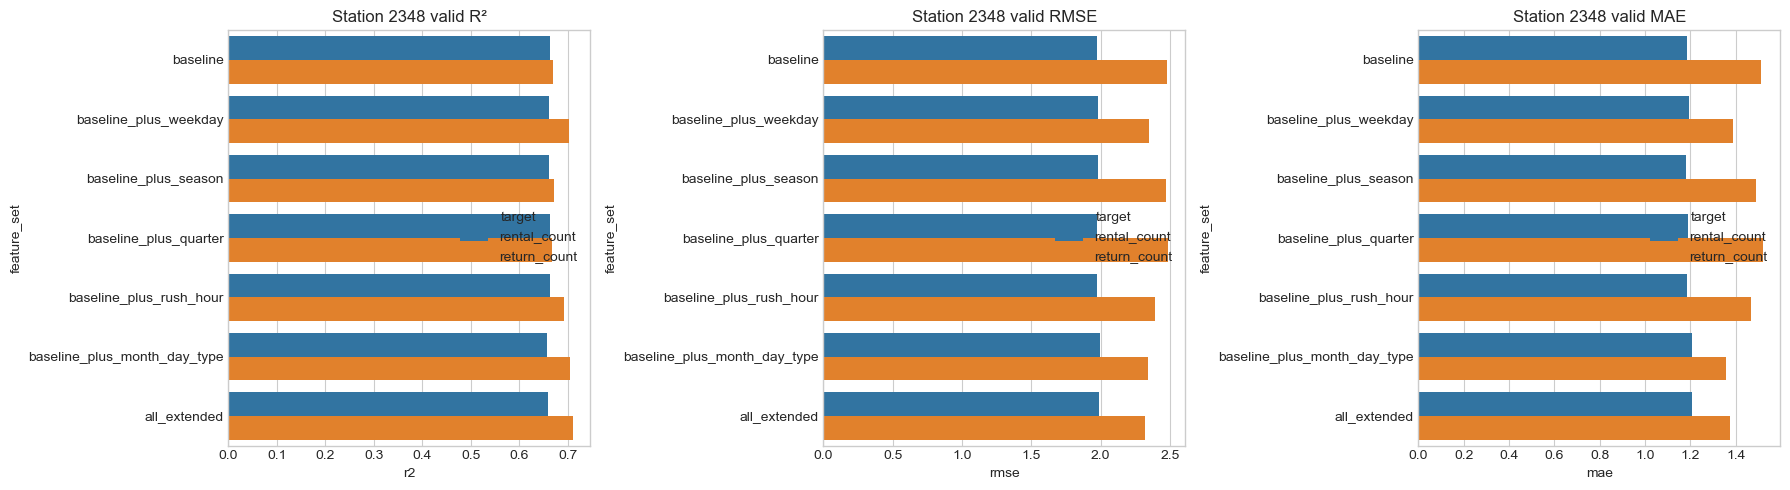

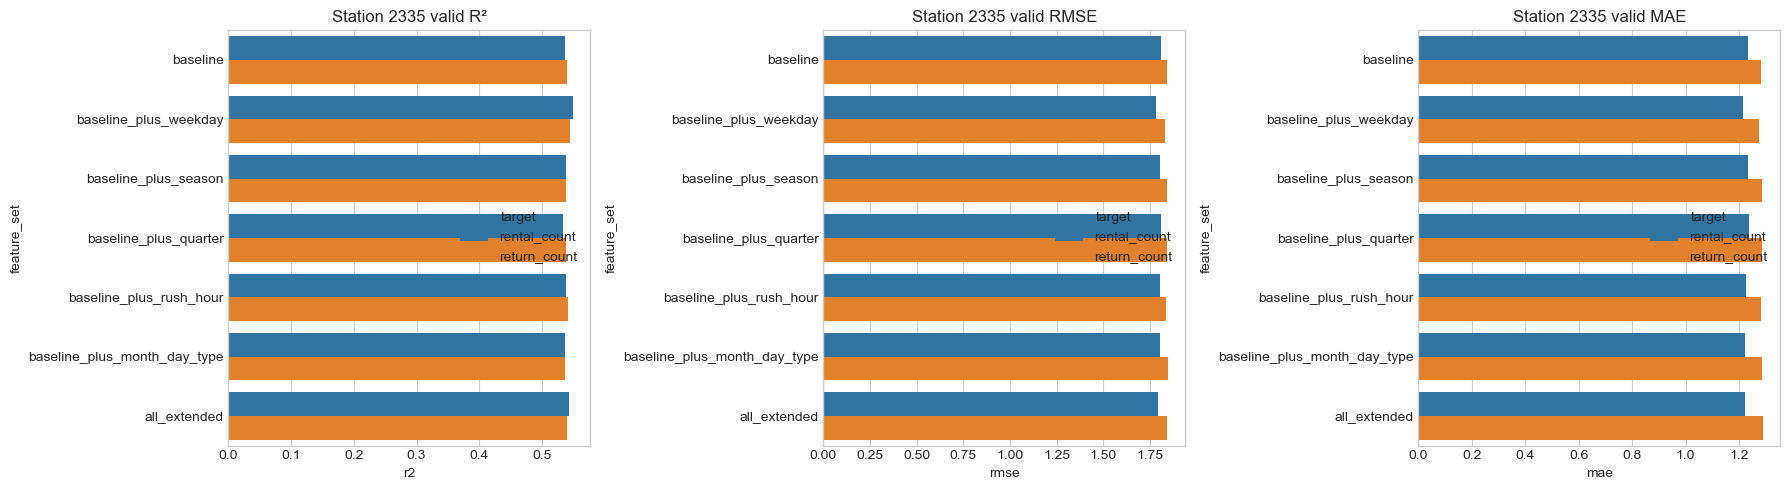

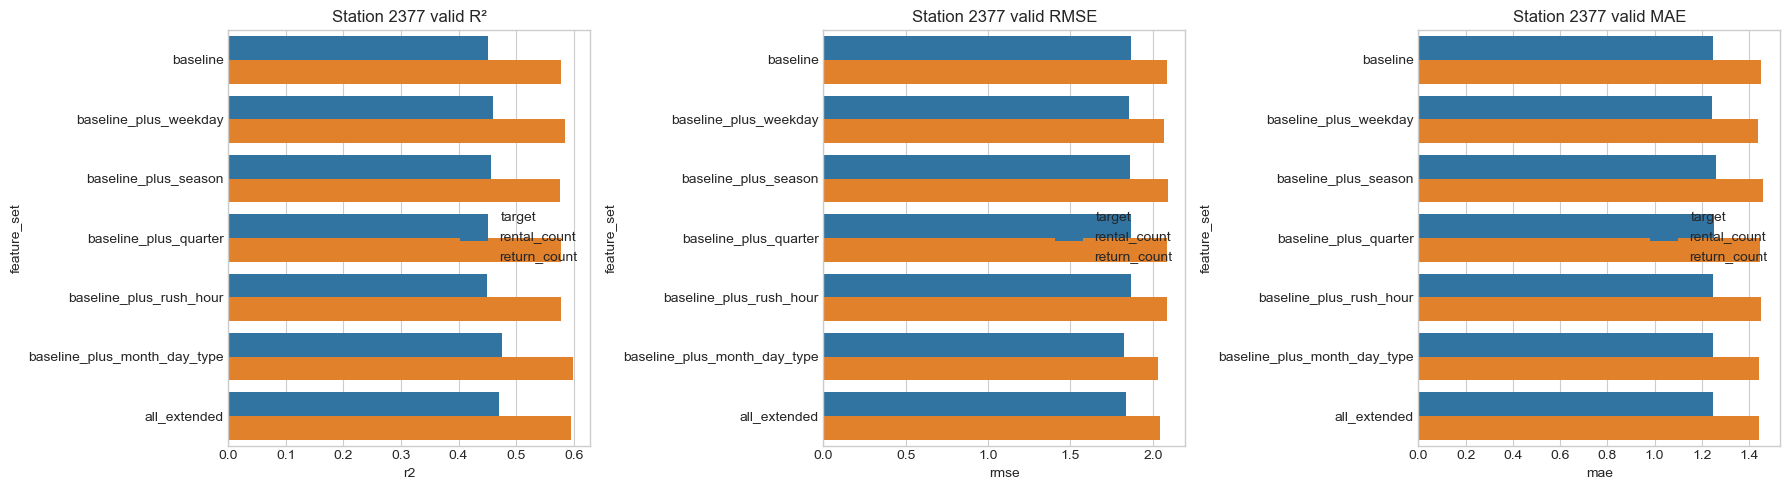

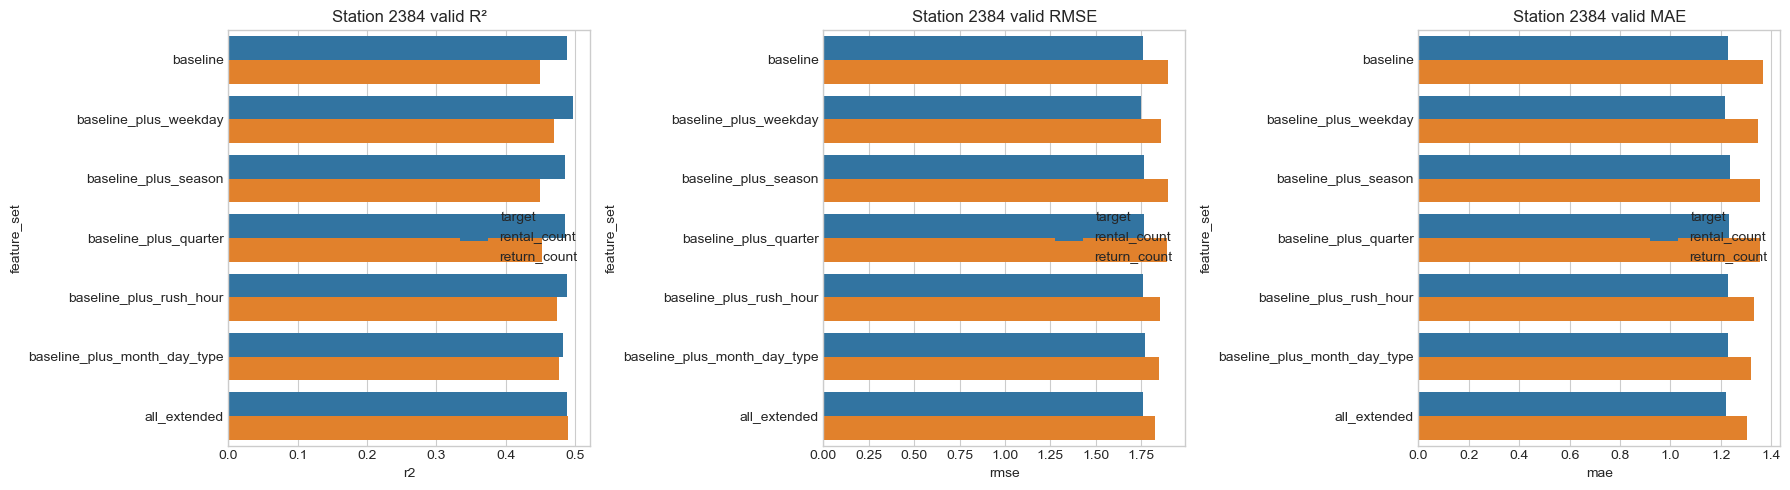

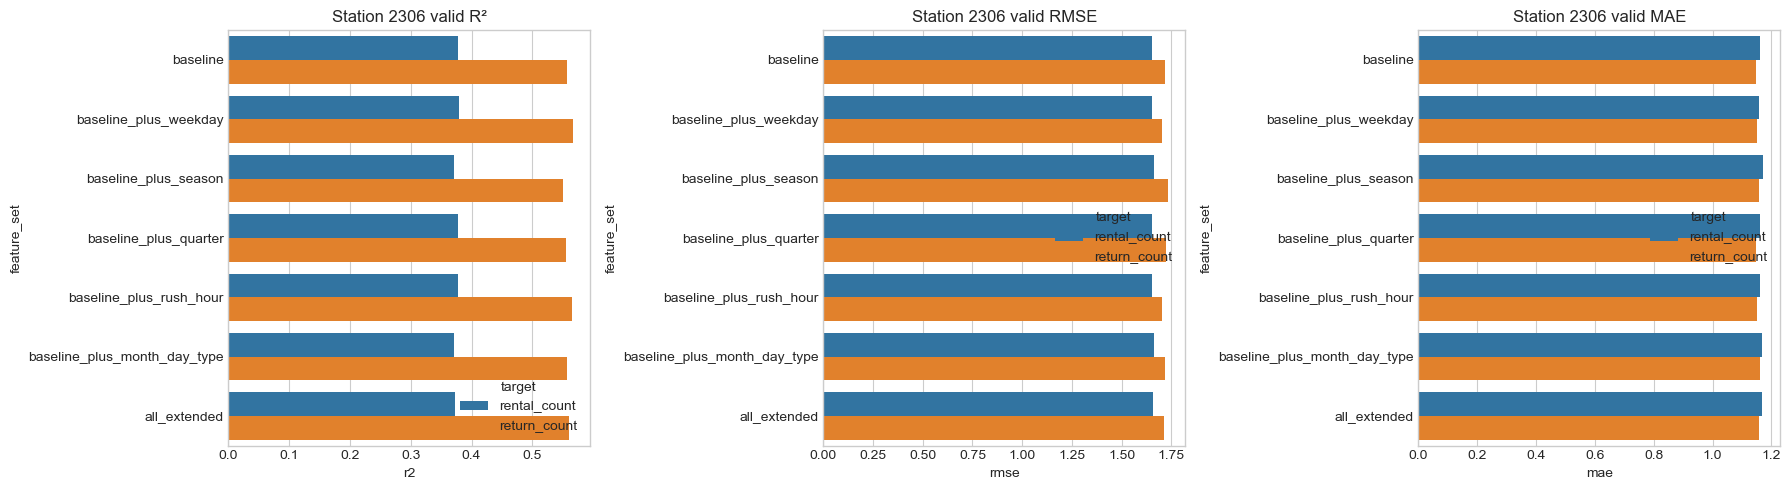

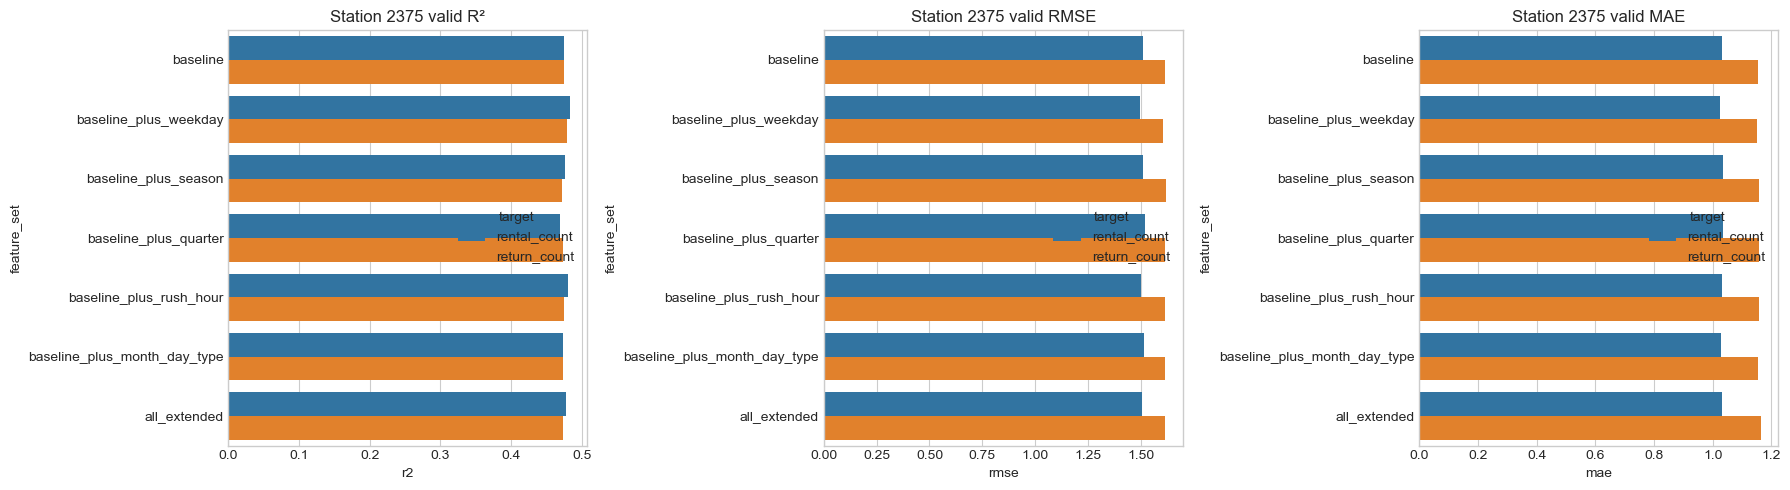

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
for station_id in TOP6_STATION_IDS:
    station_view = metrics_df[(metrics_df['station_id'] == station_id) & (metrics_df['split'] == 'valid')].copy()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.barplot(data=station_view, x='r2', y='feature_set', hue='target', ax=axes[0])
    axes[0].set_title(f'Station {station_id} valid R²')
    sns.barplot(data=station_view, x='rmse', y='feature_set', hue='target', ax=axes[1])
    axes[1].set_title(f'Station {station_id} valid RMSE')
    sns.barplot(data=station_view, x='mae', y='feature_set', hue='target', ax=axes[2])
    axes[2].set_title(f'Station {station_id} valid MAE')
    plt.tight_layout()
    plt.show()


## 11. 저장된 결과 파일

실험 결과는 아래 summary 파일로 저장됩니다.

In [15]:
saved_files = pd.DataFrame([
    {'file': str(SUMMARY_DIR / 'feature_top6_experiment_metrics.csv')},
    {'file': str(SUMMARY_DIR / 'feature_top6_best_by_target.csv')},
    {'file': str(SUMMARY_DIR / 'feature_top6_best_by_station.csv')},
    {'file': str(SUMMARY_DIR / 'feature_top6_station_optimal_summary.csv')},
    {'file': str(SUMMARY_DIR / 'feature_top6_station_interpretation.csv')},
])
saved_files

,file
0,C:\Users\TJ\ddri_work\hmw3\Data\summaries\feat...
1,C:\Users\TJ\ddri_work\hmw3\Data\summaries\feat...
2,C:\Users\TJ\ddri_work\hmw3\Data\summaries\feat...
3,C:\Users\TJ\ddri_work\hmw3\Data\summaries\feat...
4,C:\Users\TJ\ddri_work\hmw3\Data\summaries\feat...


## 12. Markdown Summary

# Feature Expansion Summary For Top 6 Stations

## 개요

이 문서는 [hmw_feature.ipynb](C:\Users\TJ\ddri_work\hmw3\feature\hmw_feature.ipynb) 실험 결과를 요약한 자료이다.  
대상은 상위 6개 station이며, 기존 `hmw_station.ipynb`의 baseline 구조를 유지한 상태에서 추가 feature를 가중치 기반으로 붙여 보며 어떤 조합이 가장 좋은 `RMSE`, `MAE`, `R²`를 만드는지 비교했다.

실험 대상 station:

- `2306` 압구정역 2번 출구 옆
- `2335` 3호선 매봉역 3번출구앞
- `2348` 포스코사거리(기업은행)
- `2375` 수서역 1번출구 앞
- `2377` 수서역 5번출구
- `2384` 자곡사거리

데이터 분할:

- `Train`: 2023년
- `Valid`: 2024년
- `Test`: 2025년

## 비교한 Feature Set

### `baseline`

기존 모델에서 사용하던 기본 feature 조합이다.

- `base_value`
- `month_weight`
- `year_weight`
- `hour_weight`
- `pattern_prior`
- `corrected_pattern_prior`
- `day_type_weekday`
- `day_type_offday`

### `baseline_plus_weekday`

요일별 차이를 추가 반영한 조합이다.

- baseline
- `weekday_weight`
- `weekday_adjusted_prior`

### `baseline_plus_season`

계절별 규모 차이를 추가 반영한 조합이다.

- baseline
- `season_weight`
- `season_adjusted_prior`

### `baseline_plus_quarter`

분기 단위 차이를 추가 반영한 조합이다.

- baseline
- `quarter_weight`
- `quarter_adjusted_prior`

### `baseline_plus_rush_hour`

출퇴근 피크 시간대 효과를 추가 반영한 조합이다.

- baseline
- `rush_hour_weight`
- `rush_hour_adjusted_prior`

### `baseline_plus_month_day_type`

월과 `weekday/offday`의 결합 효과를 추가 반영한 조합이다.

- baseline
- `month_day_type_weight`
- `month_day_type_adjusted_prior`

### `all_extended`

위의 확장 feature를 전부 결합한 조합이다.

## 전체 요약

station별로 최적인 feature set이 달랐다. 즉, 모든 station에 공통으로 가장 좋은 feature가 하나로 고정되지는 않았다.

전반적인 경향은 다음과 같았다.

- `2306`, `2335`, `2375`는 `weekday` 계열 feature를 추가했을 때 가장 안정적으로 개선됐다.
- `2377`은 `month × day_type` 조합이 가장 잘 맞아, 월별 패턴과 평일/비근무일 차이를 함께 반영하는 것이 중요했다.
- `2348`, `2384`는 더 많은 확장 feature를 함께 쓰는 것이 유리했고, 특히 `2348`은 피크 시간대와 복합 보정 효과가 컸다.

## Station별 결과 해석

### `2306` 압구정역 2번 출구 옆

- `rental_count`: `baseline_plus_weekday`
  - `R²`: `0.3770 -> 0.3788`로 거의 변화 없거나 매우 소폭 개선
  - `RMSE`: `1.6549 -> 1.6525`로 아주 소폭 개선
  - `MAE`: `1.1608 -> 1.1569`로 아주 소폭 개선
- `return_count`: `baseline_plus_weekday`
  - `R²`: `0.5576 -> 0.5666`로 소폭 개선
  - `RMSE`: `1.7205 -> 1.7029`로 개선
  - `MAE`: `1.1473 -> 1.1496`로 거의 변화 없고 아주 미세하게 악화
- 종합:
  - `baseline_plus_weekday`
  - 요일 차이를 추가했을 때 가장 안정적이었지만, 개선 폭은 전체적으로 크지 않은 편이다.
  - 해석:
    - 압구정역 출구 바로 옆이라는 입지 특성상, 생활권 이동과 지하철 연계 수요가 꾸준히 발생하는 station으로 볼 수 있다.
    - 이런 station은 패턴 자체가 아주 복잡하기보다는 평일과 주말, 또는 요일별 이동 강도의 차이가 조금씩 누적되는 경우가 많아 `weekday_weight`가 잔차를 줄이는 데 도움을 준 것으로 해석할 수 있다.
    - 다만 개선 폭이 크지 않다는 점은, 역세권 고정 수요가 강해서 기존 시간 패턴만으로도 이미 대부분의 변동이 설명되고 있음을 뜻한다.

### `2335` 3호선 매봉역 3번출구앞

- `rental_count`: `baseline_plus_weekday`
  - `R²`: `0.5365 -> 0.5492`로 소폭 개선
  - `RMSE`: `1.8079 -> 1.7829`로 개선
  - `MAE`: `1.2319 -> 1.2160`로 개선
- `return_count`: `baseline_plus_weekday`
  - `R²`: `0.5397 -> 0.5452`로 소폭 개선
  - `RMSE`: `1.8421 -> 1.8312`로 개선
  - `MAE`: `1.2838 -> 1.2730`로 개선
- 종합:
  - `baseline_plus_weekday`
  - 평일/요일별 흐름 차이를 반영했을 때 세 지표가 모두 좋아졌다.
  - 해석:
    - 매봉역 출구 앞이라는 점에서 출퇴근 통행과 지하철 환승 보조 수요가 핵심인 station으로 볼 수 있다.
    - 이런 역세권 station은 시간대 패턴은 유사해도 월요일부터 금요일, 금요일과 주말 직전 같은 세부 요일 차이가 실제 이용량에 반영될 수 있다.
    - 그래서 `weekday_weight`를 넣으면 시간 패턴 위에 요일별 규모 차이를 한 번 더 보정할 수 있어 성능이 고르게 개선됐다.

### `2348` 포스코사거리(기업은행)

- `rental_count`: `baseline_plus_rush_hour`
  - `R²`: `0.6638 -> 0.6638`로 사실상 변화 없음
  - `RMSE`: `1.9736 -> 1.9736`으로 변화 없음
  - `MAE`: `1.1840 -> 1.1858`로 아주 미세하게 악화
- `return_count`: `all_extended`
  - `R²`: `0.6702 -> 0.7106`으로 뚜렷하게 개선
  - `RMSE`: `2.4764 -> 2.3197`로 크게 개선
  - `MAE`: `1.5107 -> 1.3764`로 크게 개선
- 종합:
  - `all_extended`
  - 이 station은 단순 월/시간 보정보다 출퇴근 시간, 요일, 월-비근무일 결합 효과를 함께 반영하는 편이 더 유리했다.
  - 해석:
    - 포스코사거리와 기업은행 인근이라는 점에서 전형적인 강남 업무지구형 station 특성을 가진다.
    - 이런 곳은 출퇴근 시간대의 급격한 수요 변화, 평일 중심 수요, 월별 업무일수 차이, 비근무일 패턴 변화가 동시에 작용하기 쉽다.
    - `rental_count`는 특히 출근/퇴근 피크의 국소적 변화가 중요해서 `rush_hour`가 효과적이었다.
    - `return_count`는 요일, 계절, 월-비근무일 조합까지 함께 들어간 `all_extended`에서 크게 좋아졌는데, 이는 반납 패턴이 단일 규칙보다 여러 조건의 결합으로 결정되는 업무지구형 station의 성격을 잘 보여준다.

### `2375` 수서역 1번출구 앞

- `rental_count`: `baseline_plus_weekday`
  - `R²`: `0.4757 -> 0.4838`로 소폭 개선
  - `RMSE`: `1.5100 -> 1.4984`로 개선
  - `MAE`: `1.0333 -> 1.0249`로 개선
- `return_count`: `baseline_plus_weekday`
  - `R²`: `0.4751 -> 0.4792`로 거의 변화 없거나 소폭 개선
  - `RMSE`: `1.6136 -> 1.6072`로 소폭 개선
  - `MAE`: `1.1552 -> 1.1502`로 소폭 개선
- 종합:
  - `baseline_plus_weekday`
  - 요일 차이를 반영하는 것만으로도 가장 안정적인 개선이 나왔다.
  - 해석:
    - 수서역 출구 앞은 광역철도/지하철 연계 성격이 강한 환승형 station으로 볼 수 있다.
    - 환승형 station은 하루 패턴은 비교적 안정적이지만, 실제 이용량은 요일별 통근 강도 차이에 영향을 많이 받는 경우가 많다.
    - 그래서 복잡한 확장 feature를 많이 넣기보다 `weekday` 계열 feature만 반영해도 잔차가 줄어들었고, 가장 효율적인 보정으로 작동했다.

### `2377` 수서역 5번출구

- `rental_count`: `baseline_plus_month_day_type`
  - `R²`: `0.4517 -> 0.4760`으로 뚜렷하게 개선
  - `RMSE`: `1.8682 -> 1.8264`로 개선
  - `MAE`: `1.2470 -> 1.2476`으로 사실상 변화 없음
- `return_count`: `baseline_plus_month_day_type`
  - `R²`: `0.5775 -> 0.5986`으로 뚜렷하게 개선
  - `RMSE`: `2.0871 -> 2.0343`로 개선
  - `MAE`: `1.4491 -> 1.4422`로 소폭 개선
- 종합:
  - `baseline_plus_month_day_type`
  - 이 station은 단순 월 효과보다 `월 + weekday/offday` 결합 효과가 중요했다.
  - 해석:
    - 같은 수서역 권역이라도 5번 출구 주변은 1번 출구와 다른 보행 동선이나 주변 시설 영향이 반영될 가능성이 있다.
    - 그래서 단순히 역세권 환승 수요만 보기보다, 특정 월에 평일과 비근무일 패턴이 얼마나 달라지는지가 더 중요하게 작용한 것으로 보인다.
    - 단순 `month_weight`보다 `month_day_type_weight`가 더 잘 맞았다는 점은, 계절성 자체보다 “특정 월의 평일/주말 운영 패턴 차이”를 잡는 것이 더 효과적이었다는 뜻이다.

### `2384` 자곡사거리

- `rental_count`: `baseline_plus_weekday`
  - `R²`: `0.4878 -> 0.4966`로 소폭 개선
  - `RMSE`: `1.7618 -> 1.7466`로 개선
  - `MAE`: `1.2286 -> 1.2161`로 개선
- `return_count`: `all_extended`
  - `R²`: `0.4490 -> 0.4902`로 뚜렷하게 개선
  - `RMSE`: `1.8967 -> 1.8245`로 개선
  - `MAE`: `1.3663 -> 1.3054`로 개선
- 종합:
  - `all_extended`
  - rental은 요일 효과 중심, return은 복합 확장 feature가 더 유리한 혼합형 패턴이었다.
  - 해석:
    - 자곡사거리는 역 출구 바로 앞보다는 교차로 생활권/업무권 이동이 섞인 지점 성격으로 볼 수 있다.
    - 이런 곳은 대여는 비교적 규칙적으로 발생하더라도, 반납은 주변 목적지나 시간대, 비근무일 활동에 따라 더 복합적으로 흔들릴 수 있다.
    - 그래서 대여 쪽은 `weekday`만으로도 충분한 보정이 가능했고, 반납 쪽은 특정 시간대, 계절, 월-비근무일 조합까지 함께 작용하는 패턴이 있는 것으로 보여 `all_extended`에서 성능이 더 좋아졌다.
    - 즉 이 station은 target별로 필요한 feature 복잡도가 다르다는 점이 특징이다.

## 최종 정리

이번 실험으로 확인된 핵심은 다음과 같다.

- station마다 최적 feature 조합이 다르다.
- `weekday`는 여러 station에서 반복적으로 유효했다.
- 일부 station은 `rush_hour`나 `month_day_type`처럼 더 구체적인 보정이 필요했다.
- `all_extended`가 항상 최고는 아니지만, 패턴이 복합적인 station에서는 가장 좋은 결과를 만들 수 있다.
- `R²`가 좋아졌다고 해서 항상 `MAE`까지 같이 좋아지는 것은 아니었다.
- 따라서 최종 feature 선택은 `R²`만이 아니라 `RMSE`, `MAE`까지 함께 보고 판단하는 것이 적절하다.
- 추가 feature가 도움이 되는 이유는, 기본 시간 패턴만으로 설명되지 않는 “요일 차이”, “피크 시간대 효과”, “월과 비근무일의 결합 효과” 같은 잔차 구조를 한 번 더 보정해주기 때문이다.

따라서 이후 운영 또는 서비스 적용 시에는 모든 station에 같은 feature 조합을 일괄 적용하기보다, station별 최적 조합을 따로 가져가는 것이 더 적절하다.

## 결과 파일

- [feature_top6_experiment_metrics.csv](C:\Users\TJ\ddri_work\hmw3\Data\summaries\feature_top6_experiment_metrics.csv)
- [feature_top6_best_by_target.csv](C:\Users\TJ\ddri_work\hmw3\Data\summaries\feature_top6_best_by_target.csv)
- [feature_top6_best_by_station.csv](C:\Users\TJ\ddri_work\hmw3\Data\summaries\feature_top6_best_by_station.csv)
- [feature_top6_station_optimal_summary.csv](C:\Users\TJ\ddri_work\hmw3\Data\summaries\feature_top6_station_optimal_summary.csv)
- [feature_top6_station_interpretation.csv](C:\Users\TJ\ddri_work\hmw3\Data\summaries\feature_top6_station_interpretation.csv)
